### emissions only include the diurnal values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import time
import scipy.signal as signal
import scipy.stats as stats
import datetime as dt
import matplotlib.colors as colors
import matplotlib.cm as cm
from pypalettes import load_cmap
# from mpl_toolkits.axes_grid.inset_locator import (inset_axes, InsetPosition,
                                                  # mark_inset)

In [17]:
# the ones that will make the job
import hmmlearn as hmm
import jax.numpy as jnp
from dynamax.hidden_markov_model import LinearAutoregressiveHMM 
import jax.random as jr

/home/diace/dynenv/lib/python3.12/site-packages/tensorflow_probability/python/internal/backend/jax/ops.py:684: DeprecationWarning: jax.core.pytype_aval_mappings is deprecated.
  jax.core.pytype_aval_mappings[onp.ndarray])


In [2]:
# plot config
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['axes.linewidth'] = 0.5

In [3]:
plt.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

In [4]:
import os
os.chdir("/home/diace/notebooks/aldo/flare/")

In [7]:
df = pd.read_csv("vlf_trainingdata_2025_piu.csv", parse_dates=True, index_col=0)
df.head()

,NAA,GOES18,state,GOES19
2024-12-17 00:00:00,NaN,NaN,0.0,0.000002
2024-12-17 00:01:00,NaN,NaN,0.0,0.000002
2024-12-17 00:02:00,NaN,NaN,0.0,0.000002
2024-12-17 00:03:00,NaN,NaN,0.0,0.000002
2024-12-17 00:04:00,NaN,NaN,0.0,0.000002


In [7]:
%matplotlib inline

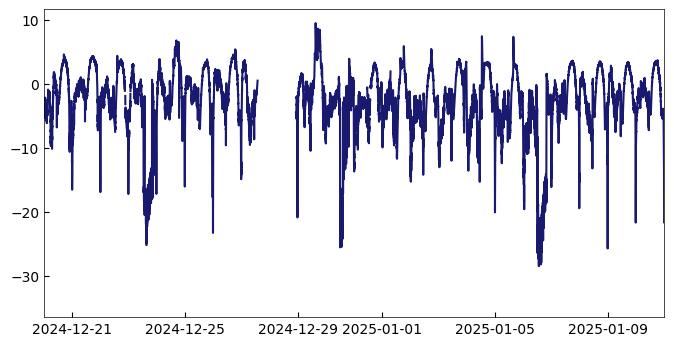

In [8]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(df["NAA"], color="midnightblue")
# ax2 = ax.twinx()
# ax2.plot(df["GOES19"], color="midnightblue")
ax.set_xlim(dt.datetime(2024, 12,20), dt.datetime(2025, 1,11))
plt.show()

In [14]:
plt.close("all")

### Quiet day curve


In [8]:
df

,NAA,GOES18,state,GOES19
2024-12-17 00:00:00,NaN,NaN,0.0,0.000002
2024-12-17 00:01:00,NaN,NaN,0.0,0.000002
2024-12-17 00:02:00,NaN,NaN,0.0,0.000002
2024-12-17 00:03:00,NaN,NaN,0.0,0.000002
2024-12-17 00:04:00,NaN,NaN,0.0,0.000002
...,...,...,...,...
2026-01-06 04:55:00,1.252027,0.000002,0.0,NaN
2026-01-06 04:56:00,1.171363,0.000001,0.0,NaN
2026-01-06 04:57:00,1.106434,0.000001,0.0,NaN
2026-01-06 04:58:00,1.198408,0.000001,0.0,NaN


In [9]:
df["time"] = df.index.time
df["date"] = df.index.date
pivotdf = df.pivot(values="NAA", columns="time", index="date")#.dropna()

In [10]:
pivot_qdc = pivotdf.rolling(window=27, center=True, min_periods=2).median()

nan @ : nan @ : nan @ : nan @ : nan @ : nan @ : nan @ : nan @ : nan @ : nan @ : nan @ : 

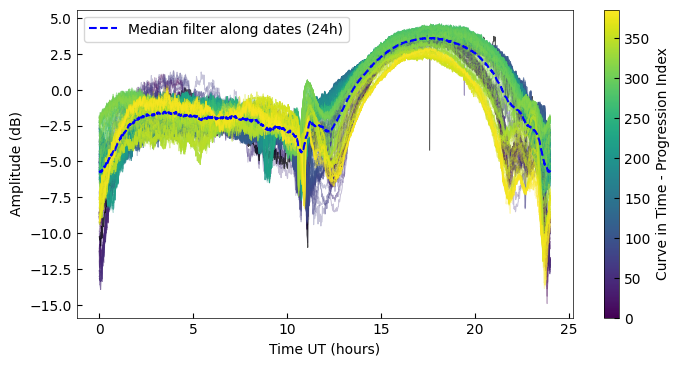

In [11]:
fig, ax = plt.subplots(figsize=(8,4))
t = np.linspace(0,24, pivot_qdc.shape[1])
threshold_mask = (15<t) & (t<20)  
# cmap = plt.get_cmap('viridis')
# cmap = plt.get_cmap('rainbow')
cmap = plt.get_cmap('viridis')

for k, row in enumerate(pivot_qdc.values[:,:]):
    # m_past = masks_perday[k-1, :].mean()
    m_curr = row[threshold_mask].mean()
    
    if m_curr>-5: # 5 as the threshold because we see it on the plot jeje
        color = cmap(k / pivot_qdc.shape[0])
        ax.plot(t, row, lw=0.75, color=color, alpha=0.3)
    else:
        print(m_curr, end=" @ : ")
        
        ax.plot(t, row, lw=0.75, color="k", alpha=0.7)
    # print(pivot_qdc.index[k])
norm = colors.Normalize(vmin=0, vmax=pivot_qdc.shape[0] - 1)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # This is required for matplotlib < 3.1, safe to leave in

ax.set_xlabel("Time UT (hours)")
ax.set_ylabel("Amplitude (dB)")
# colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Curve in Time - Progression Index')
ax.plot(t, np.mean(pivot_qdc, axis=0), lw=1.5, color="blue",ls="--",  label="Median filter along dates (24h)")
ax.legend()

In [12]:
# removing the QDC  mask
qdc_refcurve = pivot_qdc.unstack().swaplevel().sort_index()
qdc_refcurve.index = [dt.datetime.combine(qdc_refcurve.index[i][0], qdc_refcurve.index[i][1]) for i in range(len(qdc_refcurve))]
df["qdc_ref"] = qdc_refcurve
df["delta_amp"] = df["NAA"] - df["qdc_ref"]

In [13]:
# chage/ derivative of the residual
df["deriv_amp"] = np.gradient(df["delta_amp"])
df["deriv_amp"] 

2024-12-17 00:00:00         NaN
2024-12-17 00:01:00         NaN
2024-12-17 00:02:00         NaN
2024-12-17 00:03:00         NaN
2024-12-17 00:04:00         NaN
                         ...   
2026-01-06 04:55:00   -0.064309
2026-01-06 04:56:00   -0.061715
2026-01-06 04:57:00   -0.095014
2026-01-06 04:58:00    0.036126
2026-01-06 04:59:00    0.134303
Name: deriv_amp, Length: 554700, dtype: float64

In [14]:
cmap = load_cmap("spring")
plt.set_cmap(cmap)

<Figure size 640x480 with 0 Axes>

NameError: name 'df' is not defined

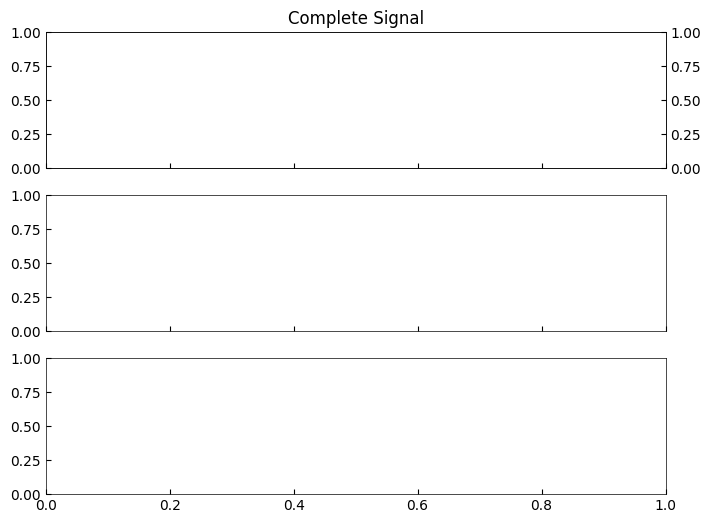

In [5]:
fig, axs = plt.subplots(nrows=3, figsize=(8,6), sharex=True)
ax = axs[0]
ax.set_title("Complete Signal")
ax2 = ax.twinx()
l1 = ax2.step(df["state"].index, df["state"], color="r", lw=0.5, label="State"); #ax2.legend()
ax2.set_ylim(-0.5, 2.5)
l2 = ax.plot(df["NAA"], label="$A{NAA}$", lw=0.75, color="black"); #ax.legend()
plt.legend(l1+l2, ["State", "NAA signal"])
ax.set_ylim(-20,15)
ax.grid(axis="x", ls="--")
ax = axs[1]
ax.plot(df["delta_amp"], label=r"$A_{NAA}-A_{bgnd}$", lw=0.75, color="darkred") ; ax.legend()
ax.grid(axis="x", ls="--")
ax = axs[2]
ax.plot(df["deriv_amp"], label=r"$d A_{NAA}/d_t$", lw=0.75, color="darkred"); ax.legend()
ax.grid(axis="x", ls="--" )
# ax.set_xlim(dt.datetime(2025,6,1), dt.datetime(2025,6,4))

(np.float64(20332.0), np.float64(20336.0))

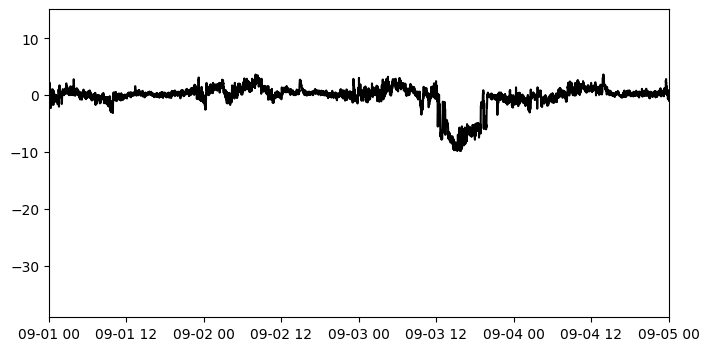

In [18]:
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(df["delta_amp"], color="k")
ax.set_xlim(dt.datetime(2025,9,1), dt.datetime(2025,9,5))

In [22]:
# pivotdf.head()
tail_of_days = 20
masks_perday = pd.DataFrame()
t = np.linspace(0,24, pivotdf.shape[1])
those = [] # those who are with extrange shape
for ii in range(pivotdf.shape[0]):
    if ii>=tail_of_days:
        ss = pivotdf.iloc[ii-tail_of_days: ii, :]
    else:  # tail of days (20 behind) fo rthe tail_len first poiunts, it will take the missing from the last ones (like a ircular buffer)
        ss = pivotdf.iloc[ : tail_of_days, :] # ok this homogenizes the curve for all points ii < tail_len
    if ss.shape[1] != 1440: continue # if the day has nodays completed
    mf = ss.median(axis=0).values
    masks_perday.loc[pivotdf.index[ii], t] = mf
    if pivotdf.index[ii] in (dt.date(2025, 1, 11), dt.date(2025, 1, 12)): 
        those.append(ss)
        # break
    print(f"{ii/pivotdf.shape[0] * 100:.2f} %", end="\r")

99.74 %

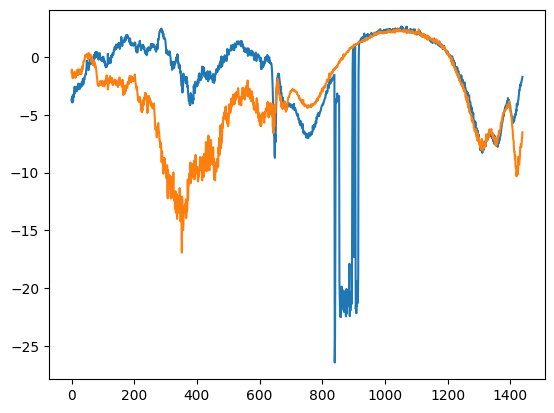

In [23]:
plt.plot(ss.values[0,:])
plt.plot(ss.values[1,:])

Text(0, 0.5, 'Amplitude (dB)')

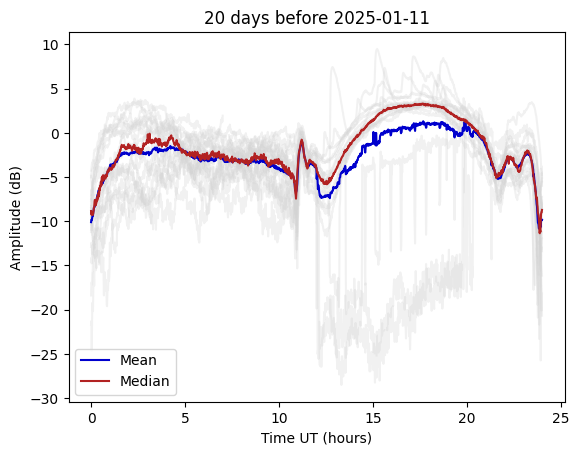

In [19]:
fig, ax  = plt.subplots()
date_ref = dt.date(2025, 1, 11)
days_behind = 20
for i in range(days_behind):
    try:
        x = pivotdf.loc[date_ref - dt.timedelta(days=i),:]
    except:
        continue
    if len(x) != 1440: continue
    ax.plot(t,x , color="lightgray", alpha=0.3)
    # ax.plot(t,x.mean(axis=0), color="lightgray", alpha=0.3)
    # ax.plot(t,x.median(axis=0), color="lightgray", alpha=0.3)
ax.plot(t, pivotdf.loc[date_ref - dt.timedelta(days=days_behind):date_ref].mean(axis=0), color="mediumblue", label="Mean")
ax.plot(t, pivotdf.loc[date_ref - dt.timedelta(days=days_behind):date_ref].median(axis=0), color="firebrick", label="Median")
ax.legend(loc="lower left")
ax.set_title(f"{days_behind} days before {date_ref}")
ax.set_xlabel("Time UT (hours)")
ax.set_ylabel("Amplitude (dB)")

NameError: name 'masks_perday' is not defined

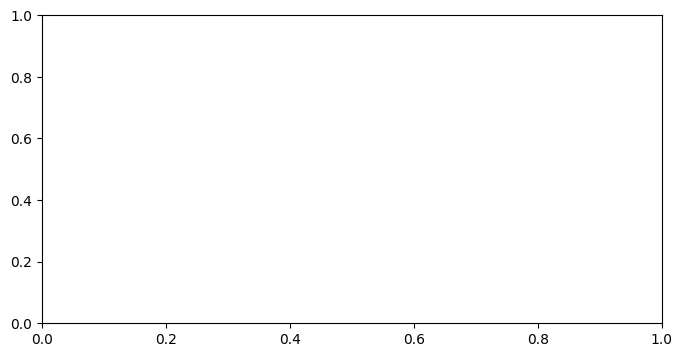

In [20]:
fig, ax = plt.subplots(figsize=(8,4))
threshold_mask = (17<t) & (t<18)  
# cmap = plt.get_cmap('viridis')
# cmap = plt.get_cmap('rainbow')
cmap = plt.get_cmap('viridis')
midday_amp = []
for k, row in enumerate(masks_perday.values[:,:]):
    # m_past = masks_perday[k-1, :].mean()
    m_curr = row[threshold_mask].mean()
    midday_amp.append(m_curr)
    if m_curr>-5: # 5 as the threshold because we see it on the plot jeje
        color = cmap(k / masks_perday.shape[0])
        ax.plot(t, row, lw=0.75, color=color, alpha=0.3)
    else:
        print(m_curr, end=" @ : ")
        print(masks_perday.index[k])
        ax.plot(t, row, lw=0.75, color="k", alpha=0.7)
norm = colors.Normalize(vmin=0, vmax=masks_perday.shape[0] - 1)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) # This is required for matplotlib < 3.1, safe to leave in

# colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Curve in Time - Progression Index')
ax.plot(t, np.mean(masks_perday, axis=0), lw=1.5, color="darkred")

NameError: name 'masks_perday' is not defined

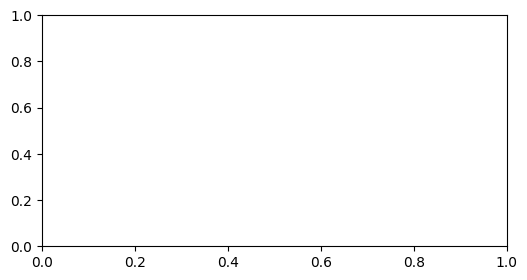

In [21]:
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(masks_perday.index, midday_amp, lw=0, marker="s", markerfacecolor="none")
ax.set_ylabel("Avg. Amp. (17-18 h UT)")
ax.set_ylabel("Date")

In [31]:
fig = plt.figure()
t = np.linspace(0,24, ss.shape[1])
plt.plot(t, masks_perday.loc[dt.date(2025,12,22)], color="b",label="Median")
# plt.plot(t, ss.mean(axis=0), color="r",label="Mean")
plt.legend()

KeyError: datetime.date(2025, 12, 22)

<Figure size 640x480 with 0 Axes>

### features from the signal

In [15]:
from jax import config
config.update("jax_enable_x64", True)

In [57]:
key = jr.PRNGKey(42)
# clean before use
mask_valid = df["delta_amp"].notna() & df["deriv_amp"].notna() & df["state"].notna()
df_clean = df[mask_valid]
# X_train = df_clean[["delta_amp", "deriv_amp"]].to_numpy()
# states = df_clean["state"].astype(int).to_numpy()

In [58]:
# only diurnal data
df_diurnal = df_clean.loc[dt.time(hour=11):dt.time(hour=23, minute=30)]
X_train = df_diurnal[["delta_amp", "deriv_amp"]].to_numpy()
states = df_diurnal["state"].astype(int).to_numpy()

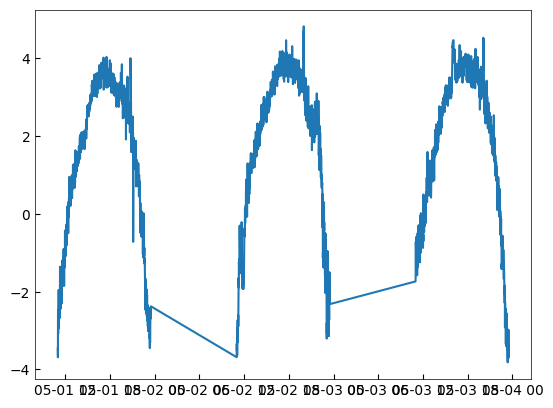

In [23]:
plt.plot(df_diurnal["NAA"].loc[dt.datetime(2025,5,1):dt.datetime(2025,5,4)])

In [56]:
len(X_train)

252262

In [71]:
### transition matrix
# states = df["state"]
# valid_mask = states.notna()
states_clean = states #states[valid_mask].astype(int)
n_states = len(np.unique(states_clean))
# count transitions
trans_counts = np.zeros((n_states, n_states))
for (i, j) in zip(states_clean[:-1], states_clean[1:]):
    trans_counts[i, j] += 1

# normlaizr
trans_mat = trans_counts / (trans_counts.sum(axis=1, keepdims=True) + 1e-6 + n_states)


states_clean

print("Transition Matrix:\n", trans_mat)

### initial probability


init_counts = df_diurnal["state"].value_counts().sort_index()
init_probs = init_counts.values / init_counts.sum()
print(f"Init probs: \n {init_probs}")

# Escalado: Normalizacion

from sklearn.preprocessing import StandardScaler as ss
scaler = ss() #standard scaler
# X_train = np.nan_to_num(X_train, nan=0.0, posinf=15.0, neginf=-10.0)
# X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
scaler.fit(X_train) 
X_train_norm =scaler.transform(X_train)
# weights and bias in AR
n_states         = 3
emission_dim      = 2 # related to residual amplitude and derivative (change rate)
emission_weights = jnp.tile(jnp.eye(emission_dim), (n_states,1,1))
emission_biases  = jnp.zeros((n_states, emission_dim))
order = 1
for k in range(n_states):
    mask = (states ==k)
    if mask.any():
        emission_biases = emission_biases.at[k].set(X_train_norm[mask].mean(axis=0))

emission_covs = jnp.tile(2 * jnp.eye(emission_dim), (n_states, 1, 1))

trans_mat_jax = jnp.array(trans_mat)
init_probs_jax = jnp.array(init_probs)


assert not jnp.isnan(init_probs_jax).any()
assert not jnp.isnan(trans_mat_jax).any()
emissions_train = jnp.array(X_train_norm)
assert not jnp.any(jnp.isnan(emissions_train)), "¡Error! X_train_norm contiene NaNs."
assert not jnp.any(jnp.isinf(emissions_train)), "¡Error! X_train_norm contiene Infinitos."

### Defining & training the model

np.any(np.isnan(X_train_norm)), np.True_ == True

t0 = time.perf_counter()

order_values = [1,2, 3, 6, 10, 15]
models = {}

Transition Matrix:
 [[0.99888526 0.00110222 0.        ]
 [0.         0.93410405 0.06520231]
 [0.03132416 0.00213574 0.96618415]]
Init probs: 
 [0.9494692  0.01713298 0.03339782]


In [72]:
def train_model_order(order, key, X_train_norm, init_probs_jax, trans_mat_jax,
                         emission_biases, emission_covs,n_states, emission_dim, niters=30):
    # to see the time of training
    t0 = time.perf_counter()
    
    arhmm = LinearAutoregressiveHMM(n_states, emission_dim, num_lags=order)
    
    print(f"> Model initialized: order = {order}")
    lagged_dim = order * emission_dim
    init_weights =  jnp.zeros((n_states, emission_dim, lagged_dim))
    init_weights = init_weights.at[:, : , :emission_dim].set(jnp.eye(emission_dim))

    #stability injection
    key, subkey_weights = jr.split(key)
    weight_noise = 1e-4 * jr.normal(subkey_weights, shape=(n_states, emission_dim, lagged_dim))
    init_weights = init_weights + weight_noise

    safe_emission_covs = emission_covs + (1e-3 * jnp.eye(emission_dim))
    params, props = arhmm.initialize(
                                    initial_probs=init_probs_jax,
                                    transition_matrix=trans_mat_jax,
                                    emission_weights=init_weights,
                                    emission_biases=emission_biases,
                                    emission_covariances=safe_emission_covs
                                    )
    key, subkey_data = jr.split(key)
    # emission_train_safe = jnp.array()
    emissions_train = jnp.array(X_train_norm) + (1e-5 * jr.normal(subkey_data, shape=X_train_norm.shape))
    inputs_train = arhmm.compute_inputs(emissions_train) 
    print("> Training the model...")
    params_fitted, log_probs = arhmm.fit_em( 
                                            params, 
                                             props, 
                                             emissions_train, 
                                             inputs=inputs_train, 
                                             num_iters=niters
                                           )

    elapsed_time = time.perf_counter() - t0
    return order, (arhmm, params_fitted, log_probs, elapsed_time)

# for order in order_values:
#     # keep the model for the order value
#     models[order] = (arhmm, params_fitted, log_probs)
#     print(f" {time.perf_counter() - t0:.4f} s")
#     t0 = time.perf_counter()
# print("> Training Finished.")

In [73]:
shared_args = {
    'X_train_norm': X_train_norm,
    'init_probs_jax': init_probs_jax,
    'trans_mat_jax': trans_mat_jax,
    'emission_biases': emission_biases,
    'emission_covs': emission_covs,
    'n_states': n_states,
    'emission_dim': emission_dim,
    'niters':15
}

In [63]:
shared_args["X_train_norm"].shape

(252262, 2)

In [74]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from joblib import Parallel, delayed
import jax

In [49]:
# parallel training multiple orders
# failed: ranout of memory
print("Training in parallel")
results = Parallel(n_jobs=len(order_values), backend="loky")(
                                                        delayed(train_model_order)(
                                                            order,
                                                            jr.fold_in(key, order),
                                                            **shared_args
                                                        ) for order in order_values
                                                )
print("finished parallel training ")
models = {order: (arhmm, params, log_probs, elapsed_time) for order, (arhmm, params, log_probs, elapsed_time) in results}

Training in parallel


E0707 17:29:20.569854 1115743 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 14.68GiB (15758131200 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0707 17:29:20.570123 1115743 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 13.21GiB (14182318080 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0707 17:29:20.570360 1115743 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 11.89GiB (12764086272 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0707 17:29:20.570592 1115743 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 10.70GiB (11487677440 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0707 17:29:20.570826 1115743 cuda_executor.cc:1273] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 9.63GiB (10338909184 byt

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [75]:
models = {}
for order in order_values:
    key, subkey = jr.split(key)
    order, result = train_model_order(order, subkey, **shared_args)
    models[order] = result

> Model initialized: order = 1
> Training the model...


<div><progress max="15" value="15"></progress> 100.00% [15/15 03:22&lt;00:00]</div>

> Model initialized: order = 2
> Training the model...


<div><progress max="15" value="15"></progress> 100.00% [15/15 03:20&lt;00:00]</div>

> Model initialized: order = 3
> Training the model...


...

<div><progress max="15" value="15"></progress> 100.00% [15/15 03:23&lt;00:00]</div>

> Model initialized: order = 10
> Training the model...


<div><progress max="15" value="15"></progress> 100.00% [15/15 00:05&lt;00:00]</div>

> Model initialized: order = 15
> Training the model...


<div><progress max="15" value="15"></progress> 100.00% [15/15 00:06&lt;00:00]</div>

In [32]:
dt.datetime.now()


datetime.datetime(2026, 7, 6, 14, 45, 19, 910295)

### Save trained models

In [76]:
import pickle
import jax
def save_models(models, scaler, fname_path="arhmm_models.pkl"):
    '''
    models: dict[order] = (arhmm, params, log_probs, elapsed_time)
    scaler: StandardScaler ajustado
    '''
    models_serializable = {}
    for order, (arhmm, params, log_probs, elapsed_time) in models.items():
        # namedtuple to numpy
        params_numpy =jax.tree_util.tree_map(np.asarray, params)
        models_serializable[order] = {
            "params":params_numpy, 
            "log_probs": log_probs, 
            "elapsed_time": elapsed_time
        }
    data = {
        "models": models_serializable,
        "scaler": scaler
    }
    with open(fname_path, "wb") as f:
        pickle.dump(data, f)
    print(f"Modls saved at {fname_path}")
    

# To load the models
def load_models(filepath, n_states=3, emission_dim=2):
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    
    scaler = data["scaler"]
    models = {}
    for order, info in data["models"].items():
        # Reconstruir modelo ARHMM vacío con el orden correspondiente
        arhmm = LinearAutoregressiveHMM(n_states, emission_dim, num_lags=order)
        # Convertir parámetros de NumPy a JAX
        params_jax = jax.tree_util.tree_map(jnp.array, info["params"])
        # Recuperar el resto
        log_probs = info["log_probs"]
        elapsed_time = info["elapsed_time"]
        models[order] = (arhmm, params_jax, log_probs, elapsed_time)
    
    print(f"Models loaded from:  {filepath}")
    return models, scaler

# Usage
# models, scaler = load_models("arhmm_models.pkl")

In [80]:
import torch

torch.cuda.empty_cache()

In [85]:
import os
import gc
import jax
# Prevent JAX from locking up all VRAM at start
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"



# Clear JAX's internal compilation and array caches
jax.clear_caches()

# Force Python to release dead references
gc.collect()

# Now try saving
save_models(models, scaler, "trained/arhmm_models_diurnal.pkl")

JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to load in-memory CUBIN (compiled for a different GPU?).: CUDA_ERROR_OUT_OF_MEMORY: out of memory [executable_name='jit_em_step']

In [83]:

save_models(models, scaler, "trained/arhmm_models_diurnal.pkl")
# models, scaler = load_models("trained/arhmm_models_diurnal.pkl")

JaxRuntimeError: RESOURCE_EXHAUSTED: [0] Failed to load in-memory CUBIN (compiled for a different GPU?).: CUDA_ERROR_OUT_OF_MEMORY: out of memory [executable_name='jit_em_step']

### Check convergency

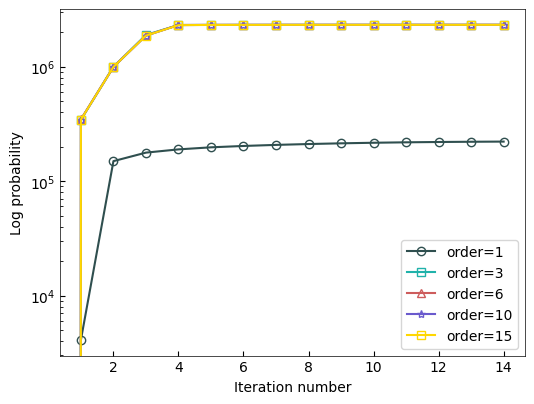

In [66]:
# convergency
marker_order = ["o", "s", "^", "*", "s"]
color_order = ['darkslategrey', 'lightseagreen', 'indianred', 'slateblue', 'gold']
fig, ax = plt.subplots(figsize=(6,4.5))
for k, (order, fit_params_) in enumerate(models.items()):
    ax.plot(fit_params_[2], label=f"order={order}", color=color_order[k], marker=marker_order[k], markerfacecolor="none")
ax.legend()    
ax.set_xlabel("Iteration number")
ax.set_ylabel("Log probability")
ax.set_yscale("log")

plt.show()

In [39]:
# %matplotlib widget

In [40]:
df_clean.head()

,NAA,GOES18,state,GOES19,time,date,qdc_ref,delta_amp,deriv_amp
2024-12-17 16:14:00,3.439003,0.000002,0.0,0.000002,16:14:00,2024-12-17,3.470031,-0.031028,16.090334
2024-12-17 16:15:00,3.441335,0.000002,0.0,0.000002,16:15:00,2024-12-17,3.405918,0.035417,0.018677
2024-12-17 16:16:00,3.438579,0.000002,0.0,0.000002,16:16:00,2024-12-17,3.432253,0.006326,-0.038329
2024-12-17 16:17:00,3.430763,0.000002,0.0,0.000002,16:17:00,2024-12-17,3.472005,-0.041241,-0.000259
2024-12-17 16:18:00,3.464595,0.000002,0.0,0.000002,16:18:00,2024-12-17,3.458786,0.005809,0.061034


### small validation

In [67]:
len(df_diurnal), len(X_train_norm)

(252262, 252262)

In [68]:
# models
# trans_mat_jax
# 4.8905349e-04, 4.8905349e-04+1e-6

state_color = {s:x for s,x in enumerate(["limegreen", "firebrick", "darkorange"])}

states_train_pred = {}
# naive visual verification
# plot only the signal at the top
for k, order in enumerate(order_values, start=1):
    print(f"processing for order={order}")
    
    result = models[order]
    (arhmm, params_fitted, log_probs, elapsed_time) = models[order]
    # X_data_norm = scaler.transform(X_data)
    emissions = jnp.array(X_train_norm)
    inputs = arhmm.compute_inputs(emissions)
    # viterbi
    # states_viterbi = arhmm.viterbi(params_fitted, emissions, inputs=inputs)
    # suavizado : forward-backward
    posterior = arhmm.smoother(params_fitted, emissions, inputs=inputs)
    states_max_prob = jnp.argmax(posterior.smoothed_probs, axis=1)
    states_train_pred[order] = states_max_prob
    # plotting
print("--- Done")

processing for order=1
processing for order=3
processing for order=6
processing for order=10
processing for order=15


In [44]:
df_diurnal.head()

,NAA,GOES18,state,GOES19,time,date,qdc_ref,delta_amp,deriv_amp
2024-12-17 16:14:00,3.439003,0.000002,0.0,0.000002,16:14:00,2024-12-17,3.470031,-0.031028,16.090334
2024-12-17 16:15:00,3.441335,0.000002,0.0,0.000002,16:15:00,2024-12-17,3.405918,0.035417,0.018677
2024-12-17 16:16:00,3.438579,0.000002,0.0,0.000002,16:16:00,2024-12-17,3.432253,0.006326,-0.038329
2024-12-17 16:17:00,3.430763,0.000002,0.0,0.000002,16:17:00,2024-12-17,3.472005,-0.041241,-0.000259
2024-12-17 16:18:00,3.464595,0.000002,0.0,0.000002,16:18:00,2024-12-17,3.458786,0.005809,0.061034


In [69]:
for c, s in states_train_pred.items():
    df_diurnal[f"states_o{c}"] = s
df_diurnal.to_csv("trained/data_trained_diurnal_modelpreds_models_1-3-6-10-15.csv")
df_diurnal.head()

,NAA,GOES18,state,GOES19,time,date,qdc_ref,delta_amp,deriv_amp,states_o1,states_o3,states_o6,states_o10,states_o15
2024-12-17 16:14:00,3.439003,0.000002,0.0,0.000002,16:14:00,2024-12-17,3.470031,-0.031028,16.090334,1,2,2,2,2
2024-12-17 16:15:00,3.441335,0.000002,0.0,0.000002,16:15:00,2024-12-17,3.405918,0.035417,0.018677,1,2,2,2,2
2024-12-17 16:16:00,3.438579,0.000002,0.0,0.000002,16:16:00,2024-12-17,3.432253,0.006326,-0.038329,0,1,1,1,1
2024-12-17 16:17:00,3.430763,0.000002,0.0,0.000002,16:17:00,2024-12-17,3.472005,-0.041241,-0.000259,0,1,1,1,1
2024-12-17 16:18:00,3.464595,0.000002,0.0,0.000002,16:18:00,2024-12-17,3.458786,0.005809,0.061034,0,0,0,0,0


In [ ]:
fig, axs = plt.subplots(nrows=len(order_values)+1, figsize=(8,10), sharex=True)
ax= axs[0]
ax.plot(df_clean.index, df_clean["NAA"].values, "k", alpha=0.5)
for k, order in enumerate(order_values, start=1):
    ax = axs[k]    
    ax.plot(df_clean.index, states_max_prob, marker="s", color=color_order[k-1], ms=4, mfc="none")
    # ax.plot(df_clean.index, X_train_norm[:, 0], "k", alpha=0.5)
    ax.grid(ls="--", lw=0.7)
plt.show()

In [ ]:
plt.close()

In [70]:
df_diurnal

,NAA,GOES18,state,GOES19,time,date,qdc_ref,delta_amp,deriv_amp,states_o1,states_o3,states_o6,states_o10,states_o15
2024-12-17 16:14:00,3.439003,0.000002,0.0,0.000002,16:14:00,2024-12-17,3.470031,-0.031028,16.090334,1,2,2,2,2
2024-12-17 16:15:00,3.441335,0.000002,0.0,0.000002,16:15:00,2024-12-17,3.405918,0.035417,0.018677,1,2,2,2,2
2024-12-17 16:16:00,3.438579,0.000002,0.0,0.000002,16:16:00,2024-12-17,3.432253,0.006326,-0.038329,0,1,1,1,1
2024-12-17 16:17:00,3.430763,0.000002,0.0,0.000002,16:17:00,2024-12-17,3.472005,-0.041241,-0.000259,0,1,1,1,1
2024-12-17 16:18:00,3.464595,0.000002,0.0,0.000002,16:18:00,2024-12-17,3.458786,0.005809,0.061034,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-05 23:26:00,-8.091013,0.000001,0.0,0.000001,23:26:00,2026-01-05,-9.194986,1.103973,0.455800,2,0,1,0,0
2026-01-05 23:27:00,-7.863699,0.000001,0.0,0.000001,23:27:00,2026-01-05,-9.570412,1.706713,0.187095,2,0,0,0,0
2026-01-05 23:28:00,-8.014987,0.000001,0.0,0.000001,23:28:00,2026-01-05,-9.493150,1.478163,0.114874,2,0,0,0,0
2026-01-05 23:29:00,-7.903011,0.000001,0.0,0.000001,23:29:00,2026-01-05,-9.839473,1.936461,0.068119,2,0,0,0,0


### Test stage

In [140]:
import utils

In [133]:
dftest = pd.read_csv("vlf_test_2026_piu.csv", parse_dates=True, index_col=0)

In [201]:
dftest

,NAA,GOES-18_long,GOES18,state,GOES19,flare_class
2026-01-05 00:00:00,NaN,9.073950e-07,9.073950e-07,0,NaN,NaN
2026-01-05 00:01:00,NaN,9.081370e-07,9.081370e-07,0,NaN,NaN
2026-01-05 00:02:00,NaN,9.064640e-07,9.064640e-07,0,NaN,NaN
2026-01-05 00:03:00,NaN,9.074515e-07,9.074515e-07,0,NaN,NaN
2026-01-05 00:04:00,NaN,9.117205e-07,9.117205e-07,0,NaN,NaN
...,...,...,...,...,...,...
2026-04-08 23:55:00,NaN,1.191676e-06,1.191676e-06,0,NaN,NaN
2026-04-08 23:56:00,NaN,1.139580e-06,1.139580e-06,0,NaN,NaN
2026-04-08 23:57:00,NaN,1.101085e-06,1.101085e-06,0,NaN,NaN
2026-04-08 23:58:00,NaN,1.078067e-06,1.078067e-06,0,NaN,NaN


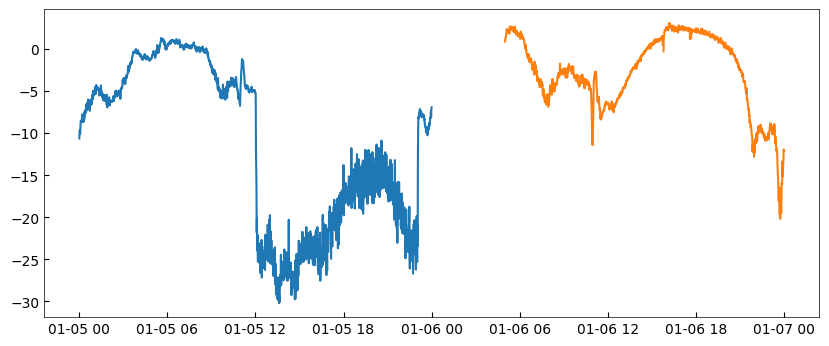

In [136]:
# fig, axs = plt.subplots(ncols=2, sharey=True, figsize=(10,4))
fig, ax = plt.subplots( sharey=True, figsize=(10,4))
# ax = axs[0]
ax.plot(df["NAA"].loc[dt.datetime(2026,1,5):dt.datetime(2026,1,6)])#.plot( ax=ax, label="2026")


# ax = axs[1]
ax.plot(dftest["NAA"].loc[dt.datetime(2026,1,6):dt.datetime(2026,1,7)]) #.plot(ax=ax)

# ax.set_xlim(dt.datetime(2026,1,6),
#            dt.datetime(2026,1,7))


In [112]:
X_train_norm

array([[        nan,         nan],
       [        nan,         nan],
       [        nan,         nan],
       ...,
       [ 0.82735937, -0.24111712],
       [ 0.80850288,  0.09093627],
       [ 0.84931618,  0.3395254 ]], shape=(554700, 2))

In [113]:
df

,NAA,GOES18,state,GOES19,time,date,qdc_ref,delta_amp,deriv_amp
2024-12-17 00:00:00,NaN,NaN,0.0,0.000002,00:00:00,2024-12-17,-8.305125,NaN,NaN
2024-12-17 00:01:00,NaN,NaN,0.0,0.000002,00:01:00,2024-12-17,-8.297318,NaN,NaN
2024-12-17 00:02:00,NaN,NaN,0.0,0.000002,00:02:00,2024-12-17,-8.098146,NaN,NaN
2024-12-17 00:03:00,NaN,NaN,0.0,0.000002,00:03:00,2024-12-17,-7.723327,NaN,NaN
2024-12-17 00:04:00,NaN,NaN,0.0,0.000002,00:04:00,2024-12-17,-7.839733,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-01-06 04:55:00,1.252027,0.000002,0.0,NaN,04:55:00,2026-01-06,-0.998643,2.250669,-0.012862
2026-01-06 04:56:00,1.171363,0.000001,0.0,NaN,04:56:00,2026-01-06,-1.083854,2.255217,-0.012343
2026-01-06 04:57:00,1.106434,0.000001,0.0,NaN,04:57:00,2026-01-06,-1.020806,2.127240,-0.019003
2026-01-06 04:58:00,1.198408,0.000001,0.0,NaN,04:58:00,2026-01-06,-0.866781,2.065189,0.007225
